# 09 — Full Analysis: putting it all together

## What you'll learn
- How `summarize()` fuses **trend, momentum, volatility, valuation and news sentiment** into one nested dict.
- How to read the `signals` list and the `bull_bear_tally` verdict.
- How to render the whole thing as a readable markdown report *inside* the notebook.
- How to rebuild the key charts (price vs SMAs, RSI, MACD, sentiment) in a single view.
- The honest limits of a descriptive report: no prediction, no probability, no recommendation.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pprint import pprint

import stocklearn
from stocklearn.data import get_history, price_series
from stocklearn.indicators import sma, rsi, macd
from stocklearn.report import summarize, format_report

sns.set_theme(style="whitegrid")

# Swap this one symbol to analyse any other stock.
ticker = "AAPL"
period = "1y"


## Where the report comes from

`summarize(ticker)` runs the whole pipeline we built across notebooks 00–08:

1. **Prices** → `get_history` (adjusted close),
2. **Trend** → 50/200-day SMAs and their relationship,
3. **Momentum** → RSI(14) and the MACD crossover,
4. **Volatility** → annualised volatility and max drawdown,
5. **Valuation** → P/E, ROE, debt/equity from the company fundamentals,
6. **Sentiment** → VADER scored over the latest headlines.

The result is a plain nested dictionary — descriptive facts, not a prediction. Let's look at each section.

In [2]:
summary = summarize(ticker, period=period)

print("ticker:", summary["ticker"])
print("as of :", summary["as_of"], "| last close:", round(summary["last_close"], 2), "| period:", summary["period"])

print("\n--- TREND ---")
pprint(summary["trend"])
print("\n--- MOMENTUM ---")
pprint(summary["momentum"])
print("\n--- VOLATILITY ---")
pprint(summary["volatility"])
print("\n--- VALUATION ---")
pprint(summary["valuation"])
print("\n--- SENTIMENT ---")
pprint(summary["sentiment"])

ticker: AAPL
as of : 2026-10-02 | last close: 333.69 | period: 1y

--- TREND ---
{'close_vs_sma200': 'above',
 'close_vs_sma50': 'above',
 'death_cross': False,
 'golden_cross': False,
 'last_cross': None,
 'last_cross_bars_ago': None,
 'regime': 'uptrend',
 'sma200': 288.79897109985353,
 'sma50': 322.3551904296875,
 'sma50_vs_sma200': 'above'}

--- MOMENTUM ---
{'macd_bearish_cross': True,
 'macd_bullish_cross': False,
 'macd_cross': 'bearish',
 'macd_histogram': -1.0182673432437044,
 'rsi': 54.73837236898058,
 'rsi_zone': 'neutral'}

--- VOLATILITY ---
{'annualized_volatility': 0.24736377200043172,
 'max_drawdown': -0.13798523953754416}

--- VALUATION ---
{'debt_to_equity': 1.3380304612588665,
 'pe_ratio': 37.876274,
 'roe': 1.5191298333175105}

--- SENTIMENT ---
{'mean_compound': -0.005099999999999988,
 'negative': 2,
 'neutral': 6,
 'positive': 2,
 'verdict': 'neutral'}


## Signals and the bull/bear tally

`signals` is a list of plain-English sentences built from the numbers above. Each is a description, not advice.

`bull_bear_tally` counts them into a simple scoreboard: the trend regime, RSI zone, MACD crossover, news
verdict and P/E bucket each contribute at most one bullish or bearish point. The verdict is just
`bullish > bearish` → bullish, `bearish > bullish` → bearish, otherwise neutral. It is a **textbook
heuristic**, not a model.

In [3]:
print("SIGNALS")
for s in summary["signals"]:
    print("  -", s)

print("\nBULL / BEAR TALLY")
print(summary["bull_bear_tally"])

SIGNALS
  - price above the 50-day SMA
  - price above the 200-day SMA
  - 50-day SMA above the 200-day SMA
  - trend regime: uptrend
  - RSI 54.7 = neutral
  - MACD bearish crossover within the last 5 bars
  - annualized volatility 24.7%, max drawdown -13.8%
  - P/E 37.9 = fair
  - return on equity 151.9%
  - debt/equity 1.34
  - news sentiment neutral (mean compound -0.01)

BULL / BEAR TALLY
{'bullish': 1, 'bearish': 1, 'verdict': 'neutral'}


## The rendered report

`format_report(summary)` turns that dictionary into markdown. We render it with `IPython.display.Markdown`
so it appears formatted — headings, tables and the disclaimer — instead of as escaped text. This is the
same output as `uv run python -m stocklearn.report AAPL`.

In [4]:
from IPython.display import Markdown, display

display(Markdown(format_report(summary)))

# AAPL — descriptive analysis

_As of 2026-10-02 · 1y of daily bars · last adjusted close $333.69_

## Trend

- **Regime: uptrend** (close vs 50-day: above, 50-day vs 200-day: above)
- 50-day SMA: $322.36 · 200-day SMA: $288.80
- Latest crossover: none in the available history

## Momentum

- RSI(14): 54.7 — neutral
- MACD(12/26/9): bearish crossover within the last 5 bars

## Volatility

- Annualized volatility: 24.7%
- Maximum drawdown: -13.8%

## Valuation

| Ratio | Value |
| --- | --- |
| P/E (trailing) | 37.9 |
| Return on equity | 151.9% |
| Debt / equity | 1.34 |

## News sentiment

- **Verdict: neutral** (mean compound -0.01 over 10 headlines)
- Positive 2 · Negative 2 · Neutral 6

| Headline | Source | Score | Tone |
| --- | --- | --- | --- |
| Apple Inc. $AAPL Stock Sold by Denver PWM LLC - MarketBeat | google-news | +0.00 | neutral |
| Mag 7 Voices: Huang Defends AI Spending, Pichai Ramps Up Gemini, Nadella Calls Copilot A ‘New OS For Work’ This Week | yfinance | +0.00 | neutral |
| AAPL Stock Heads For Worst Single-Day Fall In Over A Year — Wall Street Warns Apple’s AI Supply Chain Headwinds Are Far From Over - Stocktwits | google-news | -0.67 | negative |
| Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Service-Loss Bug | yfinance | +0.00 | neutral |
| Apple Tightens macOS Full Disk Access | yfinance | +0.00 | neutral |

## Signals

- price above the 50-day SMA
- price above the 200-day SMA
- 50-day SMA above the 200-day SMA
- trend regime: uptrend
- RSI 54.7 = neutral
- MACD bearish crossover within the last 5 bars
- annualized volatility 24.7%, max drawdown -13.8%
- P/E 37.9 = fair
- return on equity 151.9%
- debt/equity 1.34
- news sentiment neutral (mean compound -0.01)

## Bull / bear tally

Bullish 1 · Bearish 1 → **neutral**

> Educational analysis only — not financial advice. Past performance does not predict future returns.

## One view of the charts

The report is text; below we rebuild the four charts that carry the most signal. We fetch the price
frame once and reuse it, computing each indicator on the *adjusted* close (the series that already
accounts for splits and dividends).

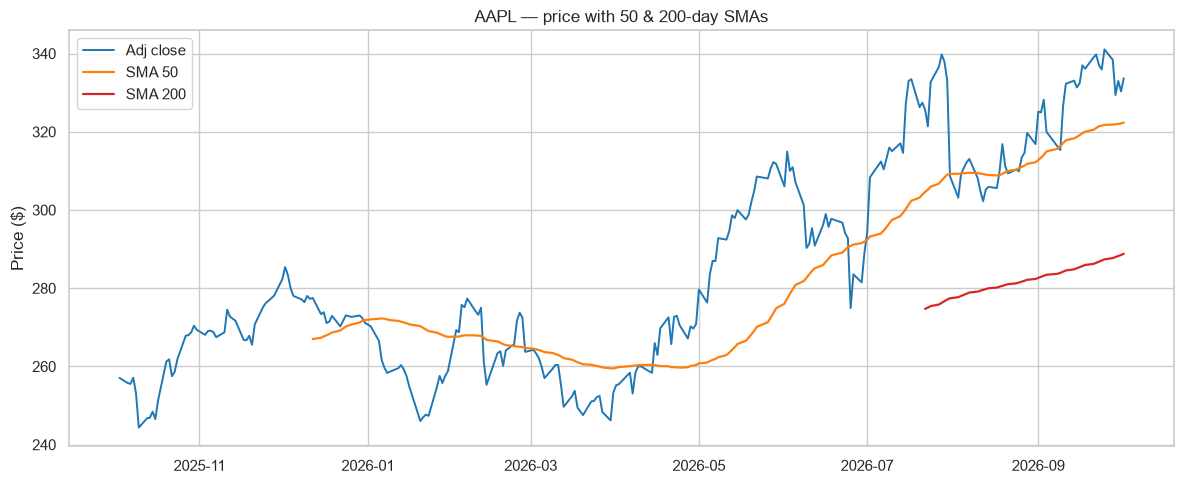

In [5]:
df = get_history(ticker, period=period)
close = price_series(df)
sma50 = sma(close, 50)
sma200 = sma(close, 200)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close.index, close, label="Adj close", color="#1f77b4", lw=1.4)
ax.plot(sma50.index, sma50, label="SMA 50", color="#ff7f0e", lw=1.6)
ax.plot(sma200.index, sma200, label="SMA 200", color="#d62728", lw=1.6)
ax.set_title(f"{ticker} — price with 50 & 200-day SMAs")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

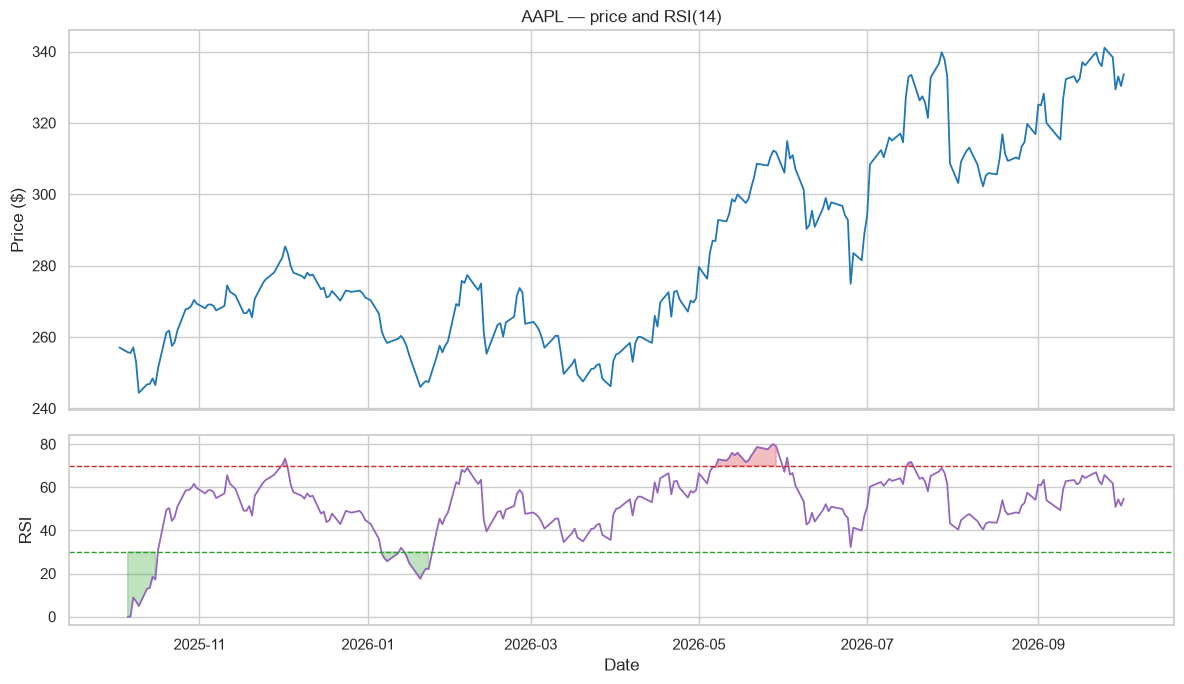

In [6]:
rsi14 = rsi(close, 14)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(close.index, close, color="#1f77b4", lw=1.3)
ax1.set_title(f"{ticker} — price and RSI(14)")
ax1.set_ylabel("Price ($)")

ax2.plot(rsi14.index, rsi14, color="#9467bd", lw=1.3)
ax2.axhline(70, color="#d62728", ls="--", lw=1)
ax2.axhline(30, color="#2ca02c", ls="--", lw=1)
ax2.fill_between(rsi14.index, 70, rsi14.where(rsi14 >= 70), color="#d62728", alpha=0.3)
ax2.fill_between(rsi14.index, 30, rsi14.where(rsi14 <= 30), color="#2ca02c", alpha=0.3)
ax2.set_ylabel("RSI")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.show()

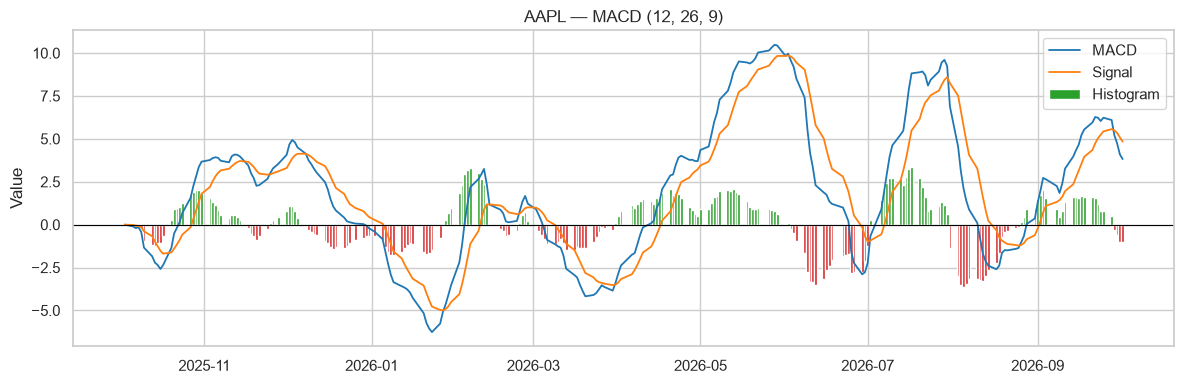

In [7]:
macd_df = macd(close)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in macd_df["hist"].fillna(0)]
ax.bar(macd_df.index, macd_df["hist"], color=colors, width=1.0, label="Histogram")
ax.plot(macd_df.index, macd_df["macd"], color="#1f77b4", lw=1.3, label="MACD")
ax.plot(macd_df.index, macd_df["signal"], color="#ff7f0e", lw=1.3, label="Signal")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"{ticker} — MACD (12, 26, 9)")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

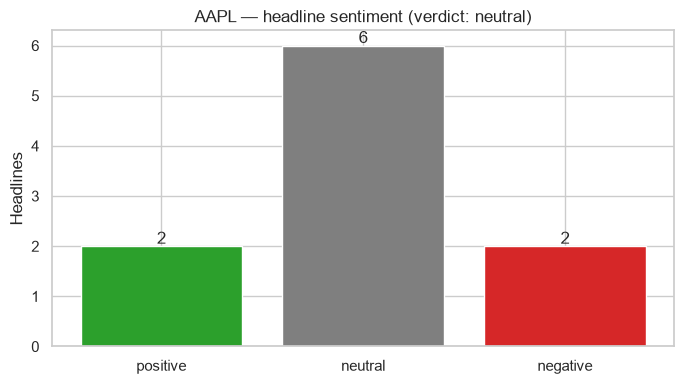

In [8]:
sent = summary["sentiment"]
labels = ["positive", "neutral", "negative"]
counts = [sent["positive"], sent["neutral"], sent["negative"]]
palette = ["#2ca02c", "#7f7f7f", "#d62728"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, counts, color=palette)
for i, c in enumerate(counts):
    ax.text(i, c + 0.05, str(c), ha="center")
ax.set_title(f'{ticker} — headline sentiment (verdict: {sent["verdict"]})')
ax.set_ylabel("Headlines")
plt.tight_layout()
plt.show()

## How to read this report

Each signal is a **description of the recent past**, not a forecast:

- **Trend regime** — `uptrend` means price > 50-day SMA > 200-day SMA. Long-horizon trend is up.
- **Golden / death cross** — the 50-day SMA crossing above (golden) or below (death) the 200-day SMA;
  a classic, slow trend-change signal that lags by construction.
- **RSI(14)** — momentum oscillator in 0–100. Above 70 = "overbought" (stretched up), below 30 =
  "oversold" (stretched down). It can stay extreme for a long time; it is not a timing signal.
- **MACD crossover** — MACD line crossing its signal line flags a shift in momentum; a fresh
  crossover within the last 5 bars is highlighted.
- **Annualised volatility** — how much the price swings per year (higher = riskier).
- **Max drawdown** — the worst peak-to-trough fall over the window (a negative number).
- **P/E** — price ÷ earnings per share: how much you pay per dollar of profit. Cheap/expensive is
  relative to the industry; we only flag very low (<15) or very high (>40) values.
- **ROE** — profit per dollar of shareholder equity; higher generally means a more efficient business.
- **Debt/equity** — leverage; higher means more borrowed money relative to equity.
- **Sentiment** — average VADER compound score of recent headlines; rule-based and easily fooled by
  sarcasm, negations and context.

## What this report is NOT

- **Not a prediction.** Nothing here estimates the probability that the price rises. It tabulates
  observable state (trend, momentum, volatility, valuation, sentiment).
- **Not a recommendation.** A tally of "4 bullish · 1 bearish" is not a buy signal.
- **Not calibrated.** Every threshold (RSI 70/30, SMA 50/200, P/E 15/40, sentiment ±0.05) is a
  textbook heuristic chosen for teaching, not fitted to data and not validated.
- **Not complete.** It ignores interest rates, macro conditions, earnings dates, position sizing,
  taxes and your own risk tolerance — all of which matter in real decisions.

> Educational analysis only — not financial advice. Past performance does not predict future returns.

## Recap / try this

1. Change `ticker` to `"MSFT"` and re-run the notebook — compare the trend regime and the P/E bucket.
2. Change `period` from `"1y"` to `"5y"` and see how `max_drawdown` and the SMAs shift.
3. Open `stocklearn/report.py` and change `CROSS_WINDOW` or `RSI_OVERBOUGHT` — watch how the signals move.
4. Delete the `get_news`-driven sentiment from the tally (set its point to 0) and see whether the verdict changes.